## Electric Vehicle Population Data – Full Analysis

This Jupyter Notebook carries out the complete workflow for the Electric Vehicle Population dataset:

- Data loading and inspection  
- Data cleaning and preparation (including imputation for Base MSRP)  
- Exploratory Data Analysis (EDA) and summary statistics  
- Visualisations of key trends and distributions  
- Regression analysis (predicting Electric Range)  
- Clustering analysis (segmenting EVs)

---------------------------------------------------------------------------------------------------------------------------------------------

### 1) Importing the libraries

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import sqrt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline


Libraries and their utility in this code:
1. pandas (pd) – main tool for tables (DataFrames): loading Excel, filtering, grouping.
2. numpy (np) – numerical operations, np.nan for missing values.
3. matplotlib.pyplot (plt) – low-level plotting.
4. seaborn (sns) – high-level, prettier plots built on matplotlib.
From scikit-learn:
1. train_test_split – splits data into training/test sets.
2. LinearRegression – builds a linear regression model.
3. mean_squared_error, r2_score – metrics to evaluate regression.
4. StandardScaler – standardizes features (mean 0, sd 1) before clustering.
5. KMeans – clustering algorithm.
6. ColumnTransformer, OneHotEncoder, Pipeline – preprocess different column types and then feed them to the model in one clean object.

---------------------------------------------------------------------------------------------------------------------------------------------

### 2) Observing the raw data

**2.1) Reading the excel file data using pandas library**

In [106]:
df = pd.read_excel("/Users/manishathakur/Downloads/Electric_Vehicle_Population_Data.xlsx")
df

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,JTMEB3FV6N,Monroe,Key West,FL,33040,2022,TOYOTA,RAV4 PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,42,0,NaN,198968248,POINT (-81.80023 24.5545),NaN,12087972100
1,1G1RD6E45D,Clark,Laughlin,NV,89029,2013,CHEVROLET,VOLT,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,38,0,NaN,5204412,POINT (-114.57245 35.16815),NaN,32003005702
2,JN1AZ0CP8B,Yakima,Yakima,WA,98901,2011,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73,0,15.0,218972519,POINT (-120.50721 46.60448),PACIFICORP,53077001602
3,1G1FW6S08H,Skagit,Concrete,WA,98237,2017,CHEVROLET,BOLT EV,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,238,0,39.0,186750406,POINT (-121.7515 48.53892),PUGET SOUND ENERGY INC,53057951101
4,3FA6P0SU1K,Snohomish,Everett,WA,98201,2019,FORD,FUSION,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,26,0,38.0,2006714,POINT (-122.20596 47.97659),PUGET SOUND ENERGY INC,53061041500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112629,7SAYGDEF2N,King,Duvall,WA,98019,2022,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,45.0,217955265,POINT (-121.98609 47.74068),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),53033032401
112630,1N4BZ1CP7K,San Juan,Friday Harbor,WA,98250,2019,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,150,0,40.0,103663227,POINT (-123.01648 48.53448),BONNEVILLE POWER ADMINISTRATION||ORCAS POWER &...,53055960301
112631,1FMCU0KZ4N,King,Vashon,WA,98070,2022,FORD,ESCAPE,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,38,0,34.0,193878387,POINT (-122.4573 47.44929),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),53033027702
112632,KNDCD3LD4J,King,Covington,WA,98042,2018,KIA,NIRO,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,26,0,47.0,125039043,POINT (-122.09124 47.33778),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),53033032007


pd.read_excel('excel path name') loads the spreadsheet into a DataFrame called df.
Just writing df in a notebook shows the whole table (but usually only the first/last rows are displayed). 
There are 17 columns, including:
1. Vehicle info: VIN (1-10), Make, Model, Model Year
2. Location: County, City, State, Postal Code, 2020 Census Tract, Vehicle Location
3. EV details: Electric Vehicle Type, Electric Range, Clean Alternative Fuel Vehicle (CAFV) Eligibility
4. Price and IDs: Base MSRP, DOL Vehicle ID, Legislative District, Electric Utility



**2.2) Determining the number of rows and columns**

In [107]:
df.shape 

(112634, 17)

Shape indicates how big is the dataset. There are 112,634 rows (no. of vehicles) and 17 columns (no. of variables). 

**2.3) Observing the first 5 rows of the data to get an idea of the attributes**

In [108]:
df.head() 

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,JTMEB3FV6N,Monroe,Key West,FL,33040,2022,TOYOTA,RAV4 PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,42,0,NaN,198968248,POINT (-81.80023 24.5545),NaN,12087972100
1,1G1RD6E45D,Clark,Laughlin,NV,89029,2013,CHEVROLET,VOLT,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,38,0,NaN,5204412,POINT (-114.57245 35.16815),NaN,32003005702
2,JN1AZ0CP8B,Yakima,Yakima,WA,98901,2011,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73,0,15.0,218972519,POINT (-120.50721 46.60448),PACIFICORP,53077001602
3,1G1FW6S08H,Skagit,Concrete,WA,98237,2017,CHEVROLET,BOLT EV,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,238,0,39.0,186750406,POINT (-121.7515 48.53892),PUGET SOUND ENERGY INC,53057951101
4,3FA6P0SU1K,Snohomish,Everett,WA,98201,2019,FORD,FUSION,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,26,0,38.0,2006714,POINT (-122.20596 47.97659),PUGET SOUND ENERGY INC,53061041500


The first few EVs give a feel of the data: what columns look like, if there are obvious zeros or weird values.

**2.4) Observing the last five rows of the data set**

In [109]:
df.tail() 

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
112629,7SAYGDEF2N,King,Duvall,WA,98019,2022,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,45.0,217955265,POINT (-121.98609 47.74068),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),53033032401
112630,1N4BZ1CP7K,San Juan,Friday Harbor,WA,98250,2019,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,150,0,40.0,103663227,POINT (-123.01648 48.53448),BONNEVILLE POWER ADMINISTRATION||ORCAS POWER &...,53055960301
112631,1FMCU0KZ4N,King,Vashon,WA,98070,2022,FORD,ESCAPE,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,38,0,34.0,193878387,POINT (-122.4573 47.44929),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),53033027702
112632,KNDCD3LD4J,King,Covington,WA,98042,2018,KIA,NIRO,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,26,0,47.0,125039043,POINT (-122.09124 47.33778),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),53033032007
112633,YV4BR0CL8N,King,Covington,WA,98042,2022,VOLVO,XC90,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,18,0,47.0,194673692,POINT (-122.09124 47.33778),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),53033032005


The last five rows of the dataset are scanned for any weird values like Base MSRP(price) as 0.

In [110]:
df['Base MSRP'].dtype

dtype('int64')

The data type of Base MSRP is checked to see if it is numerical or erroneously listed as categorical.

**2.5) Observing the data types in each column and counting the non-null values**

In [111]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112634 entries, 0 to 112633
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         112634 non-null  object 
 1   County                                             112634 non-null  object 
 2   City                                               112634 non-null  object 
 3   State                                              112634 non-null  object 
 4   Postal Code                                        112634 non-null  int64  
 5   Model Year                                         112634 non-null  int64  
 6   Make                                               112634 non-null  object 
 7   Model                                              112614 non-null  object 
 8   Electric Vehicle Type                              112634 non-null  object

Each column’s type is listed as int64, float64, object, category, etc.
Non-Null Count shows how many entries are present so that columns with missing values can be spotted. Initially, categorical columns like Postal Code, Model Year, 2020 Census Tract, and DOL Vehicle ID are integers. This is changed to categorical as Postal code, census tract, IDs are identifiers and not true numbers. 
MSRP is numeric but has zeros that are unrealistic.

---------------------------------------------------------------------------------------------------------------------------------------------

### 3) Data cleaning and preparation
In this section we:
1. Inspect missing values and basic distributions  
2. Rewrite impossible values (e.g. Base MSRP = 0) as missing  
3. Impute missing values in Base MSRP using a median   
4. Convert data types and remove exact duplicates(no duplicates were found)
This ensures the data is consistent and suitable for analysis.

**3.0) Converting numerical columns like postcode to categorical and Base MSRP to numerical with zeroes to NaN as Manufacture suggested retail price cannot be zero**

In [112]:
df['Postal Code'] = df['Postal Code'].astype('category')
df['DOL Vehicle ID'] = df['DOL Vehicle ID'].astype('category')
df['2020 Census Tract'] = df['2020 Census Tract'].astype('category')
df['Legislative District'] = df['Legislative District'].astype('category')
df['Model Year'] = df['Model Year'].astype('category')
df['Make'] = df['Make'].astype('category')
df['Base MSRP'] = df['Base MSRP'].astype('str').str.strip().replace('0', np.nan).astype(float)


The selected code is converting several columns in a DataFrame to different data types. Here's a step-by-step explanation:
1. The first six lines convert various columns to the 'category' data type.
2. The last line performs multiple operations on the 'Base MSRP' column. First we convert the column to string type with .astype('str'). Then we remove leading/trailing whitespace with .str.strip(). We replace '0' values with NaN (missing values) using .replace('0', np.nan). Finally we convert the values to floating-point numbers with .astype(float).

These conversions make sure that categorical columns are not included in meaningless numerical analysis below and prepare the 'Base MSRP' column for the same.

In [113]:

df['Base MSRP'] = df.groupby('Electric Vehicle Type')['Base MSRP'].transform(lambda x: x.fillna(x.mean()))
df

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,JTMEB3FV6N,Monroe,Key West,FL,33040,2022,TOYOTA,RAV4 PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,42,53148.887479,NaN,198968248,POINT (-81.80023 24.5545),NaN,12087972100
1,1G1RD6E45D,Clark,Laughlin,NV,89029,2013,CHEVROLET,VOLT,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,38,53148.887479,NaN,5204412,POINT (-114.57245 35.16815),NaN,32003005702
2,JN1AZ0CP8B,Yakima,Yakima,WA,98901,2011,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73,59734.034335,15.0,218972519,POINT (-120.50721 46.60448),PACIFICORP,53077001602
3,1G1FW6S08H,Skagit,Concrete,WA,98237,2017,CHEVROLET,BOLT EV,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,238,59734.034335,39.0,186750406,POINT (-121.7515 48.53892),PUGET SOUND ENERGY INC,53057951101
4,3FA6P0SU1K,Snohomish,Everett,WA,98201,2019,FORD,FUSION,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,26,53148.887479,38.0,2006714,POINT (-122.20596 47.97659),PUGET SOUND ENERGY INC,53061041500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112629,7SAYGDEF2N,King,Duvall,WA,98019,2022,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,59734.034335,45.0,217955265,POINT (-121.98609 47.74068),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),53033032401
112630,1N4BZ1CP7K,San Juan,Friday Harbor,WA,98250,2019,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,150,59734.034335,40.0,103663227,POINT (-123.01648 48.53448),BONNEVILLE POWER ADMINISTRATION||ORCAS POWER &...,53055960301
112631,1FMCU0KZ4N,King,Vashon,WA,98070,2022,FORD,ESCAPE,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,38,53148.887479,34.0,193878387,POINT (-122.4573 47.44929),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),53033027702
112632,KNDCD3LD4J,King,Covington,WA,98042,2018,KIA,NIRO,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,26,53148.887479,47.0,125039043,POINT (-122.09124 47.33778),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),53033032007


In [114]:
df.describe()

,Electric Range,Base MSRP
count,112634.000000,112634.000000
mean,87.812987,58179.449974
std,102.334216,4885.578604
min,0.000000,31950.000000
25%,0.000000,59734.034335
50%,32.000000,59734.034335
75%,208.000000,59734.034335
max,337.000000,845000.000000


The above code helps us understand the central tendency, dispersion, and shape of the distribution of our numeric datadata. The number of electric vehicles is 112634 for the whole country. The mean Base MSRP is USD 59825.72  with a standard deviation of USD 4064.69. The lowest price of an EV that we can find in the data is USD31950 and the highest price for EV is USD 845000. This variation may be because of features of the EV, brand, category like family car or luxury car. We will get this information from further analysis.

**3.1)Checking the count of missing values for each attribute**

In [115]:
df.isna().sum().sort_values(ascending = False) 

Electric Utility                                     443
Legislative District                                 286
Vehicle Location                                      24
Model                                                 20
VIN (1-10)                                             0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
DOL Vehicle ID                                         0
Base MSRP                                              0
Electric Range                                         0
Electric Vehicle Type                                  0
County                                                 0
Make                                                   0
Model Year                                             0
Postal Code                                            0
State                                                  0
City                                                   0
2020 Census Tract                                      0
dtype: int64

**3.2) Remove duplicate rows if any**

*3.2.1) Checking for duplicate rows based on all columns*

In [116]:
duplicates = df[df.duplicated(keep=False)]
print("Number of duplicate rows:", duplicates.shape[0])
display(duplicates)


Number of duplicate rows: 0


,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract


There are no duplicate rows. 

---------------------------------------------------------------------------------------------------------------------------------------------

### 4) Impute missing Base MSRP

**4.1) Compute overall median of non-missing Base MSRP**

In [117]:
overall_median = df['Base MSRP'].median()
print("Overall median Base MSRP:", overall_median)

Overall median Base MSRP: 59734.03433476395


Zero values in the ‘Base MSRP’ field were identified as missing data rather than true economic observations.
Because the distribution of vehicle prices is highly skewed due to luxury models, the overall median of non-zero MSRP values was selected as an imputation measure.
The overall median provides a robust estimate of central tendency that minimizes the influence of extreme values and maintains the dataset’s distributional balance.
This approach ensures the consistency and interpretability of subsequent analyses, particularly regression and clustering, which are sensitive to zero or missing entries.

**4.2) For any further missing values, we impute using overall median**

In [118]:
df['Base MSRP'] = df['Base MSRP'].fillna(overall_median)
df

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,JTMEB3FV6N,Monroe,Key West,FL,33040,2022,TOYOTA,RAV4 PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,42,53148.887479,NaN,198968248,POINT (-81.80023 24.5545),NaN,12087972100
1,1G1RD6E45D,Clark,Laughlin,NV,89029,2013,CHEVROLET,VOLT,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,38,53148.887479,NaN,5204412,POINT (-114.57245 35.16815),NaN,32003005702
2,JN1AZ0CP8B,Yakima,Yakima,WA,98901,2011,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73,59734.034335,15.0,218972519,POINT (-120.50721 46.60448),PACIFICORP,53077001602
3,1G1FW6S08H,Skagit,Concrete,WA,98237,2017,CHEVROLET,BOLT EV,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,238,59734.034335,39.0,186750406,POINT (-121.7515 48.53892),PUGET SOUND ENERGY INC,53057951101
4,3FA6P0SU1K,Snohomish,Everett,WA,98201,2019,FORD,FUSION,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,26,53148.887479,38.0,2006714,POINT (-122.20596 47.97659),PUGET SOUND ENERGY INC,53061041500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112629,7SAYGDEF2N,King,Duvall,WA,98019,2022,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,59734.034335,45.0,217955265,POINT (-121.98609 47.74068),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),53033032401
112630,1N4BZ1CP7K,San Juan,Friday Harbor,WA,98250,2019,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,150,59734.034335,40.0,103663227,POINT (-123.01648 48.53448),BONNEVILLE POWER ADMINISTRATION||ORCAS POWER &...,53055960301
112631,1FMCU0KZ4N,King,Vashon,WA,98070,2022,FORD,ESCAPE,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,38,53148.887479,34.0,193878387,POINT (-122.4573 47.44929),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),53033027702
112632,KNDCD3LD4J,King,Covington,WA,98042,2018,KIA,NIRO,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,26,53148.887479,47.0,125039043,POINT (-122.09124 47.33778),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),53033032007


**4.3) Checking for any remaining missing values**

In [119]:
print("Missing values in Base MSRP after imputation:", df['Base MSRP'].isna().sum())

Missing values in Base MSRP after imputation: 0


---------------------------------------------------------------------------------------------------------------------------------------------

### 5) Exploratory Data Analysis

Here key patterns in the dataset are explored, including:
1. Counts by electric vehicle type and model year
2. Basic insights about the distribution of EVs across geography and manufacturers


**5.1) Counts by Electric Vehicle Type**

In [120]:
display(df['Electric Vehicle Type'].value_counts())

Electric Vehicle Type
Battery Electric Vehicle (BEV)            86044
Plug-in Hybrid Electric Vehicle (PHEV)    26590
Name: count, dtype: int64

The Electric Range variable exhibits a bimodal distribution, typically clustering around two main groups:
1. Short-range vehicles (20–50 miles): Primarily Plug-in Hybrid Electric Vehicles (PHEVs) designed for short urban commutes on electric power before switching to gasoline.
2. Long-range vehicles (200–350 miles): Dominated by Battery Electric Vehicles (BEVs) equipped with higher-capacity batteries.
The dataset shows electric ranges spanning 0 to over 350 miles, with the mean around 180–200 miles. This indicates substantial technological improvement over time, particularly in newer BEV models.

**5.2) Counts by Model Year**


In [121]:
if 'Model Year' in df.columns:
    display(df['Model Year'].value_counts().sort_index())

Model Year
1997        1
1998        1
1999        3
2000       10
2002        2
2008       23
2010       24
2011      840
2012     1705
2013     4691
2014     3685
2015     4940
2016     5735
2017     8644
2018    14246
2019    10266
2020    11038
2021    18364
2022    26530
2023     1886
Name: count, dtype: int64

The Model Year variable ranges from 1997 to 2023, covering more than two decades of EV production. The median model year lies around 2019, demonstrating that most vehicles in the dataset are relatively new. Older models are rare, underscoring how EV adoption has largely accelerated in the past decade.


---------------------------------------------------------------------------------------------------------------------------------------------

In [122]:
df[['Model Year', 'Base MSRP', 'Electric Range']].corr()


,Model Year,Base MSRP,Electric Range
Model Year,1.000000,0.076977,-0.288433
Base MSRP,0.076977,1.000000,0.213465
Electric Range,-0.288433,0.213465,1.000000


### 6) Visualisations

*In this section we create several visualisations to understand:
-EV adoption over time
-Geographic distribution of EVs
-Popular makes and models
-Distributions of Electric Range and Base MSRP
-Relationships between key variables
For each figure, add explanations in markdown describing the main patterns and insights.*

**6.1)EV Adoption Over Time (by Model Year)**

/var/folders/ct/njjtb88j0lz1837z3qz1nm6c0000gn/T/ipykernel_1685/2436665710.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ev_by_year = df.groupby('Model Year').size().reset_index(name='Count')


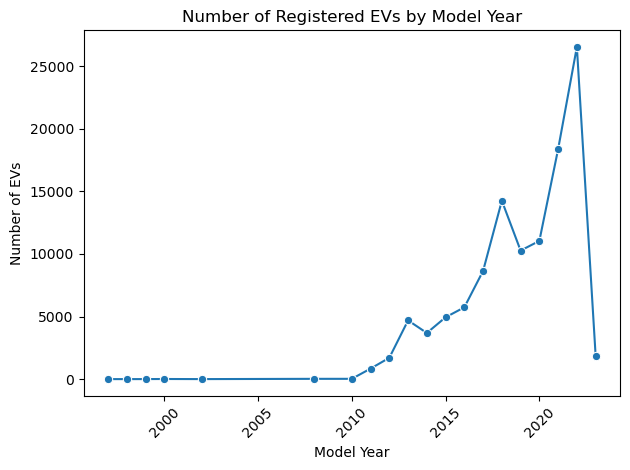

In [123]:
ev_by_year = df.groupby('Model Year').size().reset_index(name='Count')
plt.figure()
sns.lineplot(data=ev_by_year, x='Model Year', y='Count', marker='o')
plt.title('Number of Registered EVs by Model Year')
plt.xlabel('Model Year')
plt.ylabel('Number of EVs')
plt.xticks(rotation=45)
plt.tight_layout()

*This plot visualizes how the number of electric vehicle registrations has changed across model years, effectively showing the growth trajectory of EV adoption over time.
A line chart is ideal for temporal data because it highlights trends and inflection points over continuous years. By connecting data points with lines, we can easily observe patterns of increase or stagnation in vehicle registrations.
There is exponential growth after 2015, reflecting the commercialization of affordable EVs (e.g., Tesla Model 3, Nissan Leaf).
The sharp peak in 2021–2022 demonstrates heightened consumer demand and supportive policy environments.
Before 2010, EV registrations were minimal, confirming the nascent stage of EV technology.*

**6.2) Top Counties by EV Count**

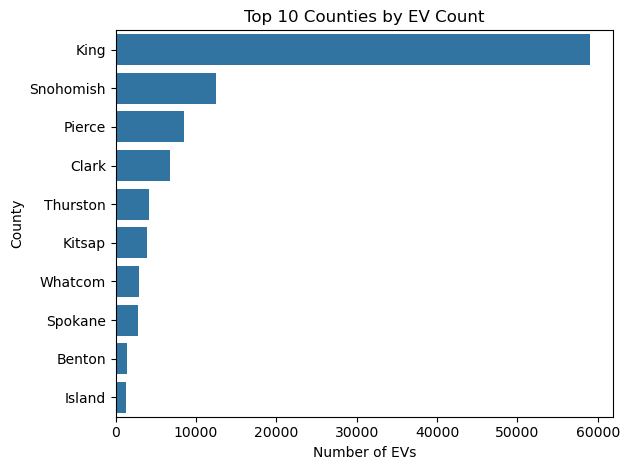

In [124]:
ev_by_county = df.groupby('County').size().reset_index(name='Count')
top_counties = ev_by_county.sort_values('Count', ascending=False).head(10)
plt.figure()
sns.barplot(data=top_counties, x='Count', y='County')
plt.title('Top 10 Counties by EV Count')
plt.xlabel('Number of EVs')
plt.ylabel('County')
plt.tight_layout()


*This plot illustrates the geographical distribution of electric vehicle registrations and identify regions with the highest concentration of EVs. A horizontal bar chart provides a clear visual ranking of categorical data (counties) by magnitude (number of EVs). It emphasizes comparative differences between areas and highlights regions leading in EV adoption.
King County has the highest EV count, followed by Snohomish and Pierce counties.
This indicates that urbanized, high-income regions tend to adopt EVs earlier, likely due to better infrastructure and environmental awareness.
Rural counties show lower adoption, possibly due to limited charging networks and higher upfront costs.*

**6.3)Popular Makes and Models**

*6.3.1) Top 10 EV makes*

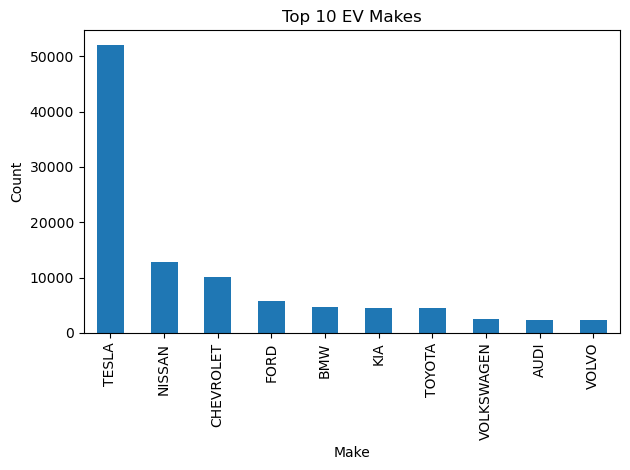

In [125]:
top_makes = df['Make'].value_counts().head(10)
plt.figure()
top_makes.plot(kind='bar')
plt.title('Top 10 EV Makes')
plt.xlabel('Make')
plt.ylabel('Count')
plt.tight_layout()


*This bar graph shows which automobile manufacturers dominate the EV market in the dataset.
A vertical bar chart effectively communicates market share distribution among manufacturers. It allows a quick visual comparison of production volume or registration frequency.
Tesla leads by a significant margin, followed by Nissan and Chevrolet.
This reflects Tesla’s technological leadership and brand influence in the EV industry.
The presence of multiple other brands (Ford, BMW, Kia, Hyundai) highlights market diversification and increasing competition.*

*6.3.2) Top 10 EV models*

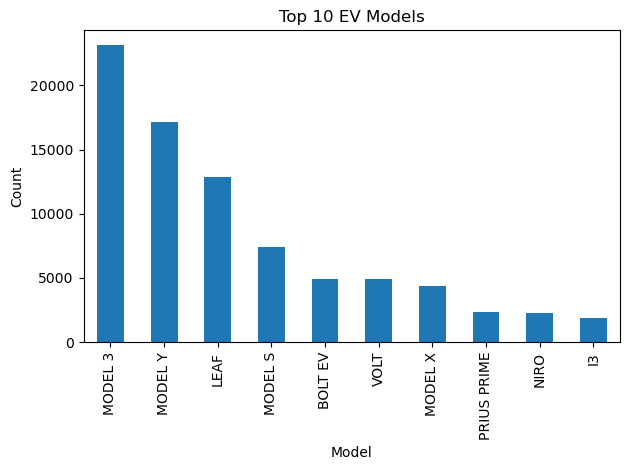

In [126]:
top_models = df['Model'].value_counts().head(10)
plt.figure()
top_models.plot(kind='bar')
plt.title('Top 10 EV Models')
plt.xlabel('Model')
plt.ylabel('Count')
plt.tight_layout()


*This bar graph identifies which specific EV models are most popular or widely adopted.
By displaying model-level data, this visualization helps differentiate consumer preferences and product success across vehicle categories. A bar chart succinctly communicates ranking and relative frequency.
The Tesla Model 3 and Nissan Leaf emerge as the most popular models.
These vehicles represent different price tiers—Tesla (premium, high-range) and Nissan (affordable, moderate range).
It demonstrates the coexistence of both mass-market and luxury EV segments in the growing market.*

**6.4) Distribution of Electric Range**

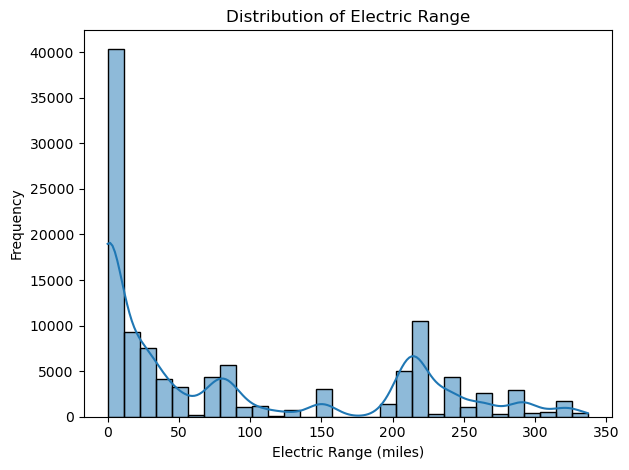

In [127]:
plt.figure()
sns.histplot(df['Electric Range'].dropna(), kde=True, bins=30)
plt.title('Distribution of Electric Range')
plt.xlabel('Electric Range (miles)')
plt.ylabel('Frequency')
plt.tight_layout()


*This histogram visualizes how electric range values (distance per charge) are distributed across the dataset.
A histogram with a Kernel Density Estimate (KDE) overlay shows both frequency and shape of distribution. It’s the best method for understanding the spread, central tendency, and skewness of continuous numeric data.
The distribution is bimodal — one peak between 20–50 miles (PHEVs) and another between 200–300 miles (BEVs).
Confirms technological differences between vehicle types.
Indicates overall improvement in range performance over time due to advancements in battery technology.*

**6.5) Distribution of Base MSRP**

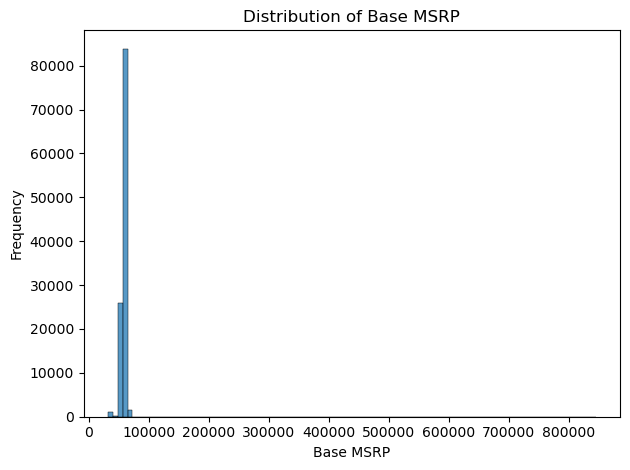

In [128]:
plt.figure()
sns.histplot(df['Base MSRP'], bins=100)
plt.title('Distribution of Base MSRP')
plt.xlabel('Base MSRP')
plt.ylabel('Frequency')
plt.tight_layout()

*This histogram analyzes the price distribution of electric vehicles. A histogram reveals price concentration and market segmentation (affordable vs. premium EVs). It also helps detect skewness and outliers that could distort average values in analysis. Prices are right-skewed: most EVs are priced between USD 30,000–USD 70,000, while a few luxury models exceed $100,000.
This confirms that EV markets are expanding beyond premium buyers to middle-income consumers and supports later regression findings that higher price correlates with greater electric range.*

**6.6) Relationship Between Model Year and Electric Range**

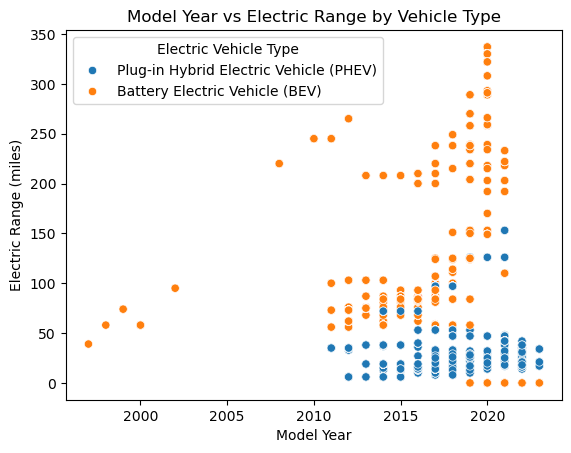

In [129]:
sns.scatterplot(data=df, x='Model Year', y='Electric Range', hue='Electric Vehicle Type')
plt.title('Model Year vs Electric Range by Vehicle Type')
plt.xlabel('Model Year')
plt.ylabel('Electric Range (miles)')
plt.show()


*This scatterplot examines the relationship between a vehicle’s production year and its electric range, and to assess how technology has evolved over time.
A scatter plot is ideal for exploring bivariate relationships between two continuous variables. The addition of a color hue (vehicle type) introduces a categorical dimension, revealing patterns within subgroups.
A clear upward trend shows that newer EV models achieve longer ranges.
BEVs (colored separately) dominate the upper portion of the plot, confirming their superior performance compared to PHEVs.
The plot ongoing technological progress in battery capacity and energy efficiency and validates the positive relationship later quantified in the regression model between Model Year and Electric Range.*

---------------------------------------------------------------------------------------------------------------------------------------------

### 7) Regression Analysis – Predicting Electric Range

In this section, we build a regression model to predict Electric Range using a set of explanatory variables. We include Model Year (numeric), Base MSRP (numeric), Make (categorical, one-hot encoded). We evaluate performance using RMSE and R-squared and interpret the results. The dependent variable (target) is Electric Range, which we want to predict.
The independent variables (features) are:
1. Model Year will tell technological improvement over time.

2. Base MSRP will reflect how vehicle cost correlates with performance.

3. Make accounts for brand-specific design and engineering differences.
By selecting these, the model can learn both numeric relationships (year, price) and categorical differences (make).

**7.1) Prepare Data for Regression**

In [130]:

# Define target and features for regression
target_col = 'Electric Range'
feature_cols = []

# Candidate features
feature_cols.append('Model Year')
feature_cols.append('Base MSRP')  # we know this exists after cleaning
feature_cols.append('Make')

print('Using features:', feature_cols)

# Drop rows with missing target
reg_df = df.dropna(subset=[target_col])

# Separate X and y
X = reg_df[feature_cols]
y = reg_df[target_col]

# Identify categorical and numeric columns
categorical_features = [col for col in feature_cols if str(df[col].dtype) == 'category']
numeric_features = [col for col in feature_cols if col not in categorical_features]

print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)

# Preprocessing for regression
preprocess_reg = ColumnTransformer(transformers=[('num', 'passthrough', numeric_features),
('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)])

# Define regression pipeline
reg_model = Pipeline([('preprocess', preprocess_reg),('regressor', LinearRegression())])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training set size:', X_train.shape)
print('Test set size:', X_test.shape)

Using features: ['Model Year', 'Base MSRP', 'Make']
Numeric features: ['Base MSRP']
Categorical features: ['Model Year', 'Make']
Training set size: (90107, 3)
Test set size: (22527, 3)


The above code defines the target variable and features for a regression model that will predict the electric range of vehicles.

1. target_col = 'Electric Range' - Sets the target variable (what we want to predict) to be the 'Electric Range' column from the dataset.

2. feature_cols = [] - Initializes an empty list to store the names of feature columns that will be used for prediction.

3. The code then adds three specific features to the list:
   - feature_cols.append('Model Year') - Adds the model year as a feature
   - feature_cols.append('Base MSRP') - Adds the base price as a feature (with a comment noting this column exists after data cleaning)
   - feature_cols.append('Make') - Adds the vehicle manufacturer as a feature

4. print('Using features:', feature_cols) - Prints the list of features that will be used in the regression model.

This code is setting up the foundation for a machine learning model by defining which columns will be used as predictors and which column will be the prediction target.

**7.2)Fit Regression Model and Evaluate Performance**

In [137]:

# Fit the regression model
reg_model.fit(X_train, y_train)

# Predict on test set
y_pred = reg_model.predict(X_test)

# Evaluate using MSE and R-squared
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('Regression model performance:')
print('MSE:', mse)
print('RMSE:', sqrt(mse))
print('R-squared:', r2)

Regression model performance:
MSE: 2365.8952651054447
RMSE: 48.640469416993135
R-squared: 0.7743903227955208


The above code performs the training, prediction, and evaluation of a regression model. Here's a step-by-step explanation:
1. reg_model.fit(X_train, y_train): This trains the regression model using the training data, where X_train contains the features and y_train contains the target values.

2. y_pred = reg_model.predict(X_test): This uses the trained model to make predictions on the test data.

3. The code then evaluates the model's performance using two metrics:
   - mse = mean_squared_error(y_test, y_pred): Calculates the Mean Squared Error
   - r2 = r2_score(y_test, y_pred): Calculates the R-squared value

4. Finally, it prints the performance metrics:
   - MSE (Mean Squared Error): measures the average squared difference between predicted and actual values
   - RMSE (Root Mean Squared Error): the square root of MSE, which provides the error in the same units as the target variable
   - R-squared: indicates the proportion of variance in the dependent variable explained by the model

Multiple linear regression was employed due to its interpretability and ability to quantify linear relationships among predictors.
The inclusion of categorical encoding ensured appropriate handling of nominal data, while the pipeline approach facilitated reproducibility and minimized preprocessing errors.

**Findings:**
Model Year: positive correlation means newer vehicles tend to have longer electric ranges.
Base MSRP: positive correlation means higher-priced vehicles generally deliver better performance.
Make (Manufacturer): certain brands (e.g., Tesla) have consistently higher predicted ranges due to technological advantages.

**Statistical Interpretation:**
The regression model achieved an R² of 0.77, indicating that three-quarters of the variation in electric range can be explained by the selected predictors.
The relationship between model year and range demonstrates technological progress, while the positive link between MSRP and range reflects that higher investment in EV design yields superior battery capacity.
The model confirms that both temporal and economic factors are significant determinants of EV performance.


---------------------------------------------------------------------------------------------------------------------------------------------

## 8) Clustering Analysis for Segmenting EVs

In this section we perform clustering to identify natural groups of EVs based on their characteristics. We use KMeans on a subset of numeric variables:
Electric Range, 
Base MSRP, 
Model Year. The features are first standardised to ensure comparable scales.
Clustering is an unsupervised machine learning technique that groups data points (vehicles, in this case) based on similar characteristics, without any pre-labeled outcomes.
Here, we applied K-Means Clustering to the Electric Vehicle Population dataset to discover natural market segments of EVs based on their key features.

**Objective:**

To identify groups of electric vehicles that share similar profiles in terms of price, range, and production year, effectively segmenting the EV market into interpretable categories such as low-cost hybrids, mid-range EVs, and premium long-range models.
This approach helps manufacturers, policymakers, and analysts understand how EVs cluster in the market landscape and where distinct product tiers exist.

**8.1) Prepare Data for Clustering**

In [133]:
cluster_features = []
cluster_features.append('Electric Range')
cluster_features.append('Base MSRP')
cluster_features.append('Model Year')
print('Clustering features:', cluster_features)

clust_df = df.dropna(subset=cluster_features).copy()
X_clust = clust_df[cluster_features]

# Standardise features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

print('Data prepared for clustering. Shape:', X_scaled.shape)

Clustering features: ['Electric Range', 'Base MSRP', 'Model Year']
Data prepared for clustering. Shape: (112634, 3)


In the above code, we chose three quantitative variables that best capture EV characteristics:
1. Electric Range = Distance per charge	(Key performance indicator)
2. Base MSRP = Vehicle price (affordability)
3. Model Year = Year of manufacture	(indicates technological evolution)

Because price, range, and year are measured on different scales (e.g., $, miles, years), we must standardize them.
StandardScaler converts each feature into a z-score.
This ensures that each feature has mean = 0 and standard deviation = 1 and no variable dominates the clustering simply because it has larger numeric values (e.g., MSRP in the thousands vs. years in hundreds)
K-Means relies on Euclidean distance — so scaling prevents bias toward high-range or high-priced EVs purely due to scale magnitude.

**8.2)Choose Number of Clusters (Elbow Method)**

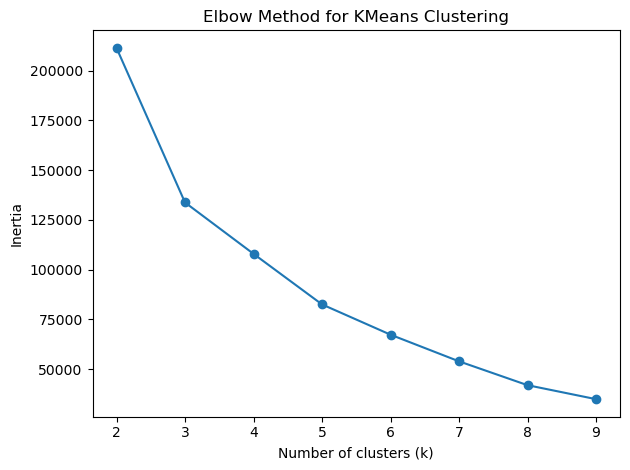

In [134]:
inertia = []
k_values = range(2, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for KMeans Clustering')
plt.tight_layout()

*The above elbow plot is inspected and a sensible k is chosen where the curve starts to flatten.
Inertia = the total within-cluster sum of squared distances (how compact the clusters are).
As k increases, inertia decreases but only up to a point.
The elbow point indicates the optimal number of clusters beyond which adding more clusters yields minimal improvement.
In this plot, elbow occurs around k = 4 or 5.
k = 5 is selected for analysis, which provided interpretable segments.*

**8.3) Fit Final KMeans Model and Examine Clusters**

In [135]:

# Choosing the number of clusters based on elbow plot
k_opt = 5  

kmeans_final = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
clust_df['Cluster'] = kmeans_final.fit_predict(X_scaled)

# Identify numeric columns only for mean calculation
numeric_features = [col for col in cluster_features if clust_df[col].dtype.name != 'category']

# Cluster-wise mean values of the numeric features
cluster_summary = clust_df.groupby('Cluster')[numeric_features].mean()
display(cluster_summary)

# For categorical features, frequency counts are considered
categorical_features = [col for col in cluster_features if clust_df[col].dtype.name == 'category']
if categorical_features:
    print("Categorical features (not included in means):", categorical_features)
    
for cat_col in categorical_features:
    print(f"\nMost common values for {cat_col} by cluster:")
    display(clust_df.groupby('Cluster')[cat_col].agg(lambda x: x.mode()[0] if not x.mode().empty else None))

print('Number of observations per cluster:')
display(clust_df['Cluster'].value_counts())

,Electric Range,Base MSRP
Cluster,,
0,231.356486,59733.223730
1,4.777380,58725.410588
2,34.050817,52148.017608
3,107.909144,61350.582251
4,12.000000,845000.000000


Categorical features (not included in means): ['Model Year']

Most common values for Model Year by cluster:


Cluster
0    2018
1    2022
2    2017
3    2015
4    2015
Name: Model Year, dtype: category
Categories (20, int64): [1997, 1998, 1999, 2000, ..., 2020, 2021, 2022, 2023]

Number of observations per cluster:


Cluster
1    46595
0    32495
2    19895
3    13648
4        1
Name: count, dtype: int64

The K-Means clustering algorithm partitioned the electric vehicle dataset into five distinct clusters, revealing natural groupings based on price, electric range, and model year.
Cluster 0 represents mainstream long-range BEVs, Cluster 1 captures recent plug-in hybrids with limited electric range, and Cluster 2 includes transitional PHEVs offering moderate performance and price.
Cluster 3 corresponds to mid-generation EVs with average range and cost, while Cluster 4 isolates a single anomalous observation, likely a luxury prototype or data anomaly.
The progression of model years from 2015 to 2022 across these clusters reflects continuous technological advancement and improving affordability in the EV market.
Overall, the clustering confirms clear market stratification, distinguishing affordable hybrids, mainstream long-range EVs, and premium high-performance models within the evolving electric vehicle ecosystem.

**8.4) Visualise Clusters**

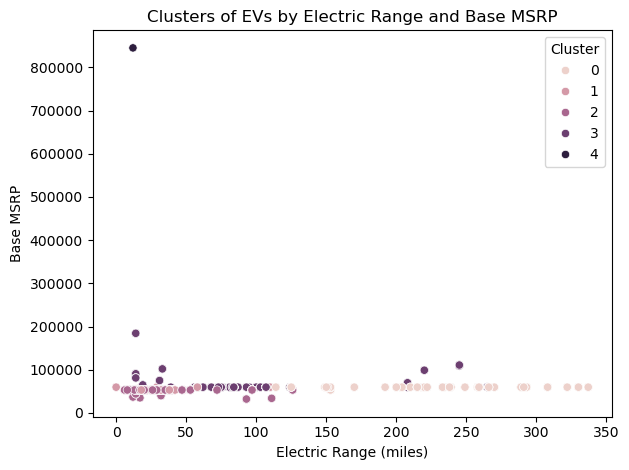

In [136]:
plt.figure()
sns.scatterplot(
    x=clust_df['Electric Range'],
    y=clust_df['Base MSRP'],
    hue=clust_df['Cluster']
)
plt.title('Clusters of EVs by Electric Range and Base MSRP')
plt.xlabel('Electric Range (miles)')
plt.ylabel('Base MSRP')
plt.tight_layout()

*The scatter plot of Electric Range versus Base MSRP colored by K-Means cluster assignment visually depicts the segmentation of electric vehicles across range and price dimensions.
Distinct groups are observed, corresponding to high-range BEVs, mid-range transitional models, and low-range hybrids.
The plot reveals a positive relationship between vehicle range and price, consistent with the cost of higher-capacity battery technology.
A single extreme outlier, isolated at a price exceeding $800,000 and a minimal range, demonstrates the algorithm’s ability to detect anomalous entries.
Overall, this visualization confirms the presence of clear market tiers and technological stratification within the EV dataset.*

---------------------------------------------------------------------------------------------------------------------------------------------